<a href="https://colab.research.google.com/github/RR77ui/Business-Intelligence/blob/main/Aprendizaje%20No%20Supervisado/Analisis%20de%20sentimientos%20NVIDIA/NVDA_sentimientos_completo_verfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Caso de negocio

### Marca seleccionada: NVIDIA (NVDA)

Elegimos a NVIDIA como objeto del análisis por tres razones concretas. Primero, es la compañía pública más correlacionada con el ciclo actual de inversión en inteligencia artificial: cualquier movimiento importante en la conversación sobre IA termina reflejándose en su precio. Segundo, el volumen de cobertura mediática sobre la empresa es alto y diverso (analistas, prensa financiera, blogs especializados), lo que asegura una base de datos rica para análisis de texto. Tercero, durante 2025 NVIDIA pasó por momentos de mucha discusión pública —restricciones de exportación a China, lanzamiento de la arquitectura Blackwell, competencia creciente de AMD con la línea MI— que generan señales interesantes para un estudio de sentimiento.

### Aclaración sobre la fuente de datos

El proyecto originalmente pedía analizar comentarios de YouTube, pero el profesor autorizó al equipo a trabajar con noticias en su lugar. La razón es práctica: para una acción como NVDA, los comentarios de YouTube tienden a ser ruido emocional (memes, hype, frustración) mientras que las noticias financieras reflejan la percepción del mercado real, que es la que afecta el precio. Para un caso de negocio orientado a decisiones de inversión, las noticias son una fuente más pertinente.

### Pregunta de negocio

¿La conversación pública sobre NVIDIA en las últimas semanas de 2025 contiene señales útiles para tomar decisiones de inversión? Específicamente:

- ¿Qué tan optimista o pesimista es el flujo de noticias sobre la empresa?
- ¿Qué temas dominan la conversación y cuáles concentran sentimiento negativo?
- ¿Existe relación entre el sentimiento agregado de las noticias y el movimiento del precio?
- ¿Qué estrategia de inversión es razonable construir a partir de estos hallazgos?

### Por qué las noticias financieras son pertinentes

A diferencia de comentarios en redes, las noticias son producidas por periodistas, analistas y casas de research que tienen acceso a información primaria (earnings calls, comunicados, fuentes corporativas). Su tono refleja el consenso del mercado profesional, que es justamente el que mueve el precio en el corto y mediano plazo. Además, Alpha Vantage entrega un score de relevancia por ticker que permite filtrar las noticias verdaderamente centradas en NVDA, lo que mejora la calidad del análisis.

### Decisiones que se pueden tomar a partir del análisis

Los resultados de este estudio están orientados a un inversionista individual o un fondo pequeño que necesita decidir cómo posicionarse en NVDA. Las decisiones concretas que se pueden derivar incluyen:

- Dimensionamiento de la posición (cuánto del portafolio destinar al activo).
- Necesidad o no de coberturas (puts, collars) frente a riesgos específicos identificados en las noticias.
- Construcción de pair-trades con competidores como AMD.
- Definición de un calendario de seguimiento atado a eventos que mueven el sentimiento (earnings, reportes de CAPEX de hyperscalers, anuncios regulatorios).

### Selección de las noticias analizadas

La base de datos se construyó usando la API de Alpha Vantage, específicamente el endpoint `NEWS_SENTIMENT`, filtrando por el ticker NVDA. El parámetro `sort=RELEVANCE` ordena los resultados por relevancia editorial y se solicitó el máximo permitido (1000 noticias) en el rango de fechas configurado.

Del total recolectado (864 noticias después de filtrar las que tenían texto completo válido), se aplicó un segundo filtro de relevancia usando el score `nvda_relevance_score` que entrega Alpha Vantage para cada noticia y cada ticker mencionado. Las **155 noticias con score mayor a 0.8** son las que se usan para el análisis de sentimiento, validación, cruce con categorías e insights.

Este filtro es importante porque muchas noticias mencionan a NVDA solo de pasada (por ejemplo, una reseña del Nasdaq que la menciona junto a otras cinco tech). Trabajar solo con las de alta relevancia asegura que el sentimiento detectado corresponde efectivamente a NVDA y no a contexto secundario.

### Limitaciones de la base de datos

Tres limitaciones importantes que el lector debe tener presente:

1. **Cobertura temporal acotada**: a pesar de que la consulta a la API se hizo con un rango amplio, los resultados con relevancia alta para NVDA quedaron concentrados entre el 8 y el 31 de diciembre de 2025. Esto significa que el análisis refleja la percepción de fin de año, no del año completo.

2. **Sesgo de selección de la fuente**: Alpha Vantage prioriza medios financieros estadounidenses (Benzinga, Motley Fool, Finviz, Zacks). La perspectiva internacional, especialmente la asiática, queda sub-representada, lo cual es relevante para una empresa con exposición geopolítica a China.

3. **Sesgo de scraping**: no todas las URLs lograron ser scrapeadas exitosamente. Las noticias donde el texto completo no pudo extraerse fueron descartadas, lo que puede introducir un sesgo si ciertos medios tienen sistemáticamente menos accesibilidad.

##0. Importamos librerias

In [ ]:
#!pip install newspaper3k lxml lxml_html_clean beautifulsoup4 -q
import time
import random
import re
from urllib.parse import urlparse
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###1. Scrapping de las diferentes fuentes para el datset

In [ ]:
#Se utilizo la api de alpha vantage que filtra
import requests
url = 'https://www.alphavantage.co/query?function=NEWS_SENTIMENT&tickers=NVDA&time_from=20250101T0000&time_to=20260101T0000&sort=RELEVANCE&limit=1000&apikey='
r = requests.get(url)
data = r.json()

print(data)

In [ ]:
import pandas as pd

# Asumiendo que 'data' contiene la respuesta JSON de la API de Alpha Vantage
# La estructura de la API de NEWS_SENTIMENT suele tener los artículos bajo la clave 'feed'
# Es importante revisar la estructura real de 'data' si esto no funciona directamente.
if 'feed' in data:
    df = pd.DataFrame(data['feed'])
else:
    df = pd.DataFrame(data) # Intenta crear el DataFrame directamente si no hay clave 'feed'

# Mostrar las primeras filas del DataFrame
display(df.head())

In [ ]:
display(df.describe())
display(df.describe(include='object'))

In [ ]:
# Toma las URLs que estan en df y extrae el artículo completo
# Selectores específicos por fuente (las más comunes en AV para NVDA/AMD)
"""
DOMAIN_SELECTORS = {
    "investing.com":  ["div.articlePage", "div#article-content", "div.WYSIWYG"],
    "inc.com":        ["div.article-body", "div.body-content", "section.article__body"],
    "reuters.com":    ["div[class*='article-body']", "div[data-testid='paragraph']"],
    "benzinga.com":   ["div.article-content-body", "div[class*='story-content']"],
    "fool.com":       ["div.article-body", "div[class*='tailwind-article-body']"],
    "marketwatch.com":["div.article__body", "div[class*='article-wrap']"],
    "yahoo.com":      ["div.caas-body", "article"],
    "cnbc.com":       ["div.ArticleBody-articleBody", "section[data-module='ArticleBody']"],
    "stocktitan.net": ["div.news-body", "div.article-body", "div#content"],
    "techcrunch.com": ["div.article-content", "div[class*='article__content']"],
    "thestreet.com":  ["div[class*='article-body']", "div.article-body"],
    "barrons.com":    ["div[class*='article__body']", "article"],
    "wsj.com":        ["div[class*='article-content']", "section.article-content"],
    "forbes.com":     ["div.article-body", "div[class*='article-body-container']"],
}

USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/123.0.0.0 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/122.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0",
]

def get_domain(url):
    return urlparse(url).netloc.replace("www.", "")

def clean_text(text):
    if not text:
        return ""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def scrape_url(url, session):
    """Intenta extraer el texto completo de una URL."""
    if not url or not str(url).startswith("http"):
        return "", "url_invalida"

    headers = {
        "User-Agent": random.choice(USER_AGENTS),
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
    }

    try:
        time.sleep(random.uniform(2.0, 4.0))  # Delay para no ser bloqueado
        resp = session.get(url, headers=headers, timeout=20, allow_redirects=True)

        if resp.status_code == 403:
            return "", "bloqueado_403"
        if resp.status_code == 429:
            time.sleep(60)
            return "", "rate_limit"
        if resp.status_code != 200:
            return "", f"error_http_{resp.status_code}"

        soup = BeautifulSoup(resp.text, "html.parser")
        domain = get_domain(url)

        # 1. Intenta con selectores específicos del dominio
        matched = next((d for d in DOMAIN_SELECTORS if d in domain), None)
        if matched:
            for selector in DOMAIN_SELECTORS[matched]:
                elem = soup.select_one(selector)
                if elem:
                    texto = clean_text(elem.get_text(separator=" "))
                    if len(texto.split()) > 50:
                        return texto, "ok"

        # 2. Fallback: newspaper3k (genérico, funciona en casi todo)
        try:
            from newspaper import Article
            art = Article(url, language="en")
            art.download()
            art.parse()
            if art.text and len(art.text.split()) > 50:
                return clean_text(art.text), "ok"
        except Exception:
            pass

        # 3. Último fallback: todos los párrafos con más de 60 caracteres
        parrafos = soup.find_all("p")
        texto = " ".join(p.get_text(strip=True) for p in parrafos if len(p.get_text()) > 60)
        texto = clean_text(texto)
        if len(texto.split()) > 50:
            return texto, "ok"

        return "", "texto_insuficiente"

    except Exception as e:
        return "", f"error_{str(e)[:30]}"


def extraer_textos_completos(df, url_col="url", limite=None):
    """
    Agrega la columna 'texto_completo' al DataFrame existente.
    - df      : tu DataFrame de Alpha Vantage
    - url_col : nombre de la columna con las URLs (en tu df es 'url')
    - limite  : si quieres probar con solo N artículos primero
    """
    df_work = df.copy()
    if limite:
        df_work = df_work.head(limite)

    session = requests.Session()
    textos, estados = [], []
    total = len(df_work)

    for i, (_, row) in enumerate(df_work.iterrows()):
        url = row.get(url_col, "")
        print(f"[{i+1}/{total}] {str(url)[:65]}")

        texto, estado = scrape_url(str(url), session)
        textos.append(texto)
        estados.append(estado)

        palabras = len(texto.split()) if texto else 0
        print(f"         → {estado} | {palabras} palabras")

    df_work["texto_completo"]   = textos
    df_work["scraping_status"]  = estados
    df_work["palabras"]         = df_work["texto_completo"].apply(lambda x: len(x.split()) if x else 0)

    return df_work


# ── PRUEBA PRIMERO CON 5 ARTÍCULOS ───────────────────────────
# Cuando veas que funciona bien, quita limite=5 para procesar todos
df_enriquecido = extraer_textos_completos(df, url_col="url", limite=5)

# Ver resultado
display(df_enriquecido[["title", "source", "texto_completo", "palabras", "scraping_status"]])
"""

In [ ]:
"""
ok       = (df_enriquecido["scraping_status"] == "ok").sum()
total    = len(df_enriquecido)
promedio = df_enriquecido.loc[df_enriquecido["scraping_status"] == "ok", "palabras"].mean()

print("=" * 50)
print(f"  Total procesados : {total}")
print(f"  ✅ Exitosos       : {ok}")
print(f"  ❌ Fallidos       : {total - ok}")
if ok > 0:
    print(f"  📝 Prom. palabras : {promedio:.0f}")
print("=" * 50)

# Distribución de estados
print("\nEstados de scraping:")
print(df_enriquecido["scraping_status"].value_counts())

print("\nFuentes con más éxito:")
resultado_por_fuente = df_enriquecido.groupby("source")["scraping_status"].apply(
    lambda x: (x == "ok").sum()
).sort_values(ascending=False)
print(resultado_por_fuente.head(10))
"""

In [ ]:
# Descomenta esta celda cuando estés listo para procesar todo
# AVISO: puede tardar varios minutos dependiendo de cuántos artículos tengas

#df_completo = extraer_textos_completos(df, url_col="url")  # Sin limite = todos


In [ ]:
display(df_completo.describe())
display(df_completo.describe(include='object'))

In [ ]:
import os
from google.colab import drive
import pandas as pd

# 1. Mount Google Drive
print("Montando Google Drive...")
drive.mount('/content/drive')

# 2. Define the file path in Google Drive
folder_name = 'aprendizaje no supervisado'
folder_path = os.path.join('/content/drive/My Drive', folder_name)
file_name = 'noticias_NVDA_completo.csv' # Keeping the filename as per the last successful execution context
file_path = os.path.join(folder_path, file_name)

# Ensure the directory exists in Google Drive
if not os.path.exists(folder_path):
    print(f"Creando la carpeta '{folder_name}' en Google Drive...")
    os.makedirs(folder_path)
    print(f"Carpeta '{folder_name}' creada.")
else:
    print(f"La carpeta '{folder_name}' ya existe en Google Drive.")

# 3. Save the df_completo DataFrame (assuming it's already in memory)
print(f"Guardando el DataFrame 'df_completo' en '{file_path}'...")
df_completo.to_csv(file_path, index=False)
print(f"Dataset 'df_completo' guardado exitosamente en '{file_path}'.")

# Display a sample of the saved dataframe for confirmation
print("\nPrimeras 5 filas del DataFrame df_completo:")
display(df_completo.head())
print(f"Número total de filas en df_completo: {len(df_completo)}")


##2. Analisis Exploratorio del dataset

In [ ]:
df_2 = pd.read_csv('/content/drive/MyDrive/Aprendizaje no supervisado/noticias_NVDA_completo.csv')
display(df_2.describe())
display(df_2.describe(include='object'))
print('\nValores nulos por columna:')
print(df_2.isnull().sum())

,overall_sentiment_score,palabras
count,1000.000000,1000.000000
mean,0.208393,851.853000
std,0.187012,1136.236189
min,-0.705214,0.000000
25%,0.114435,362.000000
50%,0.235240,657.500000
75%,0.333249,998.250000
max,0.873086,14093.000000


,title,url,time_published,authors,summary,banner_image,source,category_within_source,source_domain,topics,overall_sentiment_label,ticker_sentiment,texto_completo,scraping_status
count,1000,1000,1000,1000,1000,627,1000,1000,1000,1000,1000,1000,864,1000
unique,954,1000,979,213,1000,534,116,1,116,987,5,1000,764,8
top,"KLA Corporation (KLAC) Stock Is Up, What You N...",https://finviz.com/news/247839/palantir-nvidia...,20251208T110800,['Khadija Saeed'],"Palantir, Nvidia, and CenterPoint Energy are c...",https://i-invdn-com.investing.com/news/world_n...,Finviz,General,Finviz,"[{'topic': 'technology', 'relevance_score': '1...",Somewhat-Bullish,"[{'ticker': 'CNP', 'relevance_score': '0.96012...",When Jeff Bezos said that one breakthrough tec...,ok
freq,3,1,3,107,1,10,151,1000,151,14,483,1,58,864



Valores nulos por columna:
title                        0
url                          0
time_published               0
authors                      0
summary                      0
banner_image               373
source                       0
category_within_source       0
source_domain                0
topics                       0
overall_sentiment_score      0
overall_sentiment_label      0
ticker_sentiment             0
texto_completo             136
scraping_status              0
palabras                     0
dtype: int64


In [ ]:
df_2 = df_2.dropna(subset=['texto_completo'])
print(f"Filas después de eliminar nulos en 'texto_completo': {len(df_2)}")
display(df_2.head())

Filas después de eliminar nulos en 'texto_completo': 864


,title,url,time_published,authors,summary,banner_image,source,category_within_source,source_domain,topics,overall_sentiment_score,overall_sentiment_label,ticker_sentiment,texto_completo,scraping_status,palabras
0,1 Healthcare Stock to Target This Week and 2 W...,https://finviz.com/news/265636/1-healthcare-st...,20251231T233800,['Petr Huřťák'],This article analyzes three healthcare stocks:...,https://news-assets.stockstory.org/cover-image...,Finviz,General,Finviz,"[{'topic': 'life_sciences', 'relevance_score':...",0.125475,Neutral,"[{'ticker': 'GEHC', 'relevance_score': '1.0000...",Healthcare companies are pushing the status qu...,ok,653
1,Cognizant Technology Solutions Corp Class A St...,https://m.economictimes.com/markets/us-stocks/...,20251231T230742,['NULL'],"This article provides live stock price data, c...","https://img.etimg.com/photo/msid-76931895,qual...",The Economic Times,General,The Economic Times,"[{'topic': 'earnings', 'relevance_score': '0.8...",0.059944,Neutral,"[{'ticker': 'CTSH', 'relevance_score': '1.0000...",Disclaimer: Data is sourced from third parties...,ok,61
2,3 Reasons to Sell CTS and 1 Stock to Buy Instead,https://finviz.com/news/265718/3-reasons-to-se...,20251231T230500,['Anthony Lee'],This article recommends selling CTS stock due ...,https://news-assets.stockstory.org/cover-image...,Finviz,General,Finviz,"[{'topic': 'earnings', 'relevance_score': '0.8...",0.064118,Neutral,"[{'ticker': 'CTS', 'relevance_score': '0.91919...","Since July 2025, CTS has been in a holding pat...",ok,542
3,"Columbus McKinnon (CMCO): Buy, Sell, or Hold P...",https://finviz.com/news/265770/columbus-mckinn...,20251231T230100,['Radek Strnad'],Columbus McKinnon (CMCO) has seen its stock ri...,https://news-assets.stockstory.org/cover-image...,Finviz,General,Finviz,"[{'topic': 'earnings', 'relevance_score': '0.9...",-0.074534,Neutral,"[{'ticker': 'CMCO', 'relevance_score': '1.0000...",Columbus McKinnon has followed the market’s tr...,ok,516
4,3 Reasons to Avoid AGNC and 1 Stock to Buy Ins...,https://finviz.com/news/265771/3-reasons-to-av...,20251231T230100,['Adam Hejl'],This article advises investors to avoid AGNC I...,https://news-assets.stockstory.org/cover-image...,Finviz,General,Finviz,"[{'topic': 'earnings', 'relevance_score': '0.9...",-0.041301,Neutral,"[{'ticker': 'AGNCP', 'relevance_score': '1.000...",AGNC Investment trades at $10.74 and has moved...,ok,545


In [ ]:
import ast

def check_nvda_sentiment(ticker_sentiment_list_str):
    try:
        # Convert string representation of list to actual list of dictionaries
        ticker_sentiment_list = ast.literal_eval(ticker_sentiment_list_str)
        for item in ticker_sentiment_list:
            if item.get('ticker') == 'NVDA':
                return {
                    'has_nvda': True,
                    'nvda_relevance_score': float(item.get('relevance_score'))
                }
        return {'has_nvda': False, 'nvda_relevance_score': None}
    except (ValueError, SyntaxError) as e:
        # Handle cases where the string is not a valid list representation
        return {'has_nvda': False, 'nvda_relevance_score': None, 'error': str(e)}

# Apply the function to the 'ticker_sentiment' column
df_2['nvda_sentiment_info'] = df_2['ticker_sentiment'].apply(check_nvda_sentiment)

# Separate the results into new columns
df_2['has_nvda_ticker'] = df_2['nvda_sentiment_info'].apply(lambda x: x['has_nvda'])
df_2['nvda_relevance_score'] = df_2['nvda_sentiment_info'].apply(lambda x: x['nvda_relevance_score'])

# Drop the intermediate column if no longer needed
df_2 = df_2.drop(columns=['nvda_sentiment_info'])

# Display the count of records with NVDA ticker
print(f"Total records with NVDA ticker: {df_2['has_nvda_ticker'].sum()}")
print(f"Total records without NVDA ticker: {(~df_2['has_nvda_ticker']).sum()}")
print(f"Promedio de relevancia de la noticia respecto al ticket analizado: {df_2['nvda_relevance_score'].mean():.4f}")
print(f"Longitud promedio de las noticias es:{df_2['palabras'].mean():.4f}")

# News with relevance score greater than 0.8 for NVDA
relevance_one_news = df_2[df_2['nvda_relevance_score'] > 0.8]
print(f"\nNúmero de noticias con relevancia mayor a 0.8 para NVDA: {len(relevance_one_news)}")
print("Títulos y URLs de las noticias con relevancia mayor a 0.8 para NVDA:")
for i, row in enumerate(relevance_one_news[['title', 'url']].iterrows()):
    print(f"{i+1}. Título: {row[1]['title']}\n   URL: {row[1]['url']}")

Total records with NVDA ticker: 864
Total records without NVDA ticker: 0
Promedio de relevancia de la noticia respecto al ticket analizado: 0.6772
Longitud promedio de las noticias es:985.9410

Número de noticias con relevancia mayor a 0.8 para NVDA: 155
Títulos y URLs de las noticias con relevancia mayor a 0.8 para NVDA:
1. Título: Advanced Micro Devices Is the Most Compelling AI Trade for 2026
   URL: https://finviz.com/news/265405/advanced-micro-devices-is-the-most-compelling-ai-trade-for-2026
2. Título: Nvidia, TSMC rise as the world’s most valuable company reportedly asks for more chips to meet Chinese demand
   URL: https://sherwood.news/markets/nvidia-tsmc-rise-as-the-worlds-most-valuable-company-reportedly-asks-for/
3. Título: Intel stock price today: INTC rises in premarket as Nvidia’s $5 billion stake takes focus
   URL: https://ts2.tech/en/intel-stock-price-today-intc-rises-in-premarket-as-nvidias-5-billion-stake-takes-focus/
4. Título: B. Riley Financial | Diversified Finan

Los 20 temas más repetidos en el dataset son:
- financial_markets: 727 veces
- technology: 680 veces
- earnings: 552 veces
- economy_macro: 198 veces
- finance: 188 veces
- manufacturing: 85 veces
- mergers_and_acquisitions: 71 veces
- energy_transportation: 69 veces
- economy_monetary: 54 veces
- life_sciences: 44 veces
- retail_wholesale: 43 veces
- blockchain: 26 veces
- economy_fiscal: 26 veces
- real_estate: 24 veces
- ipo: 15 veces


/tmp/ipykernel_13903/1458289865.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=topics, palette='viridis')


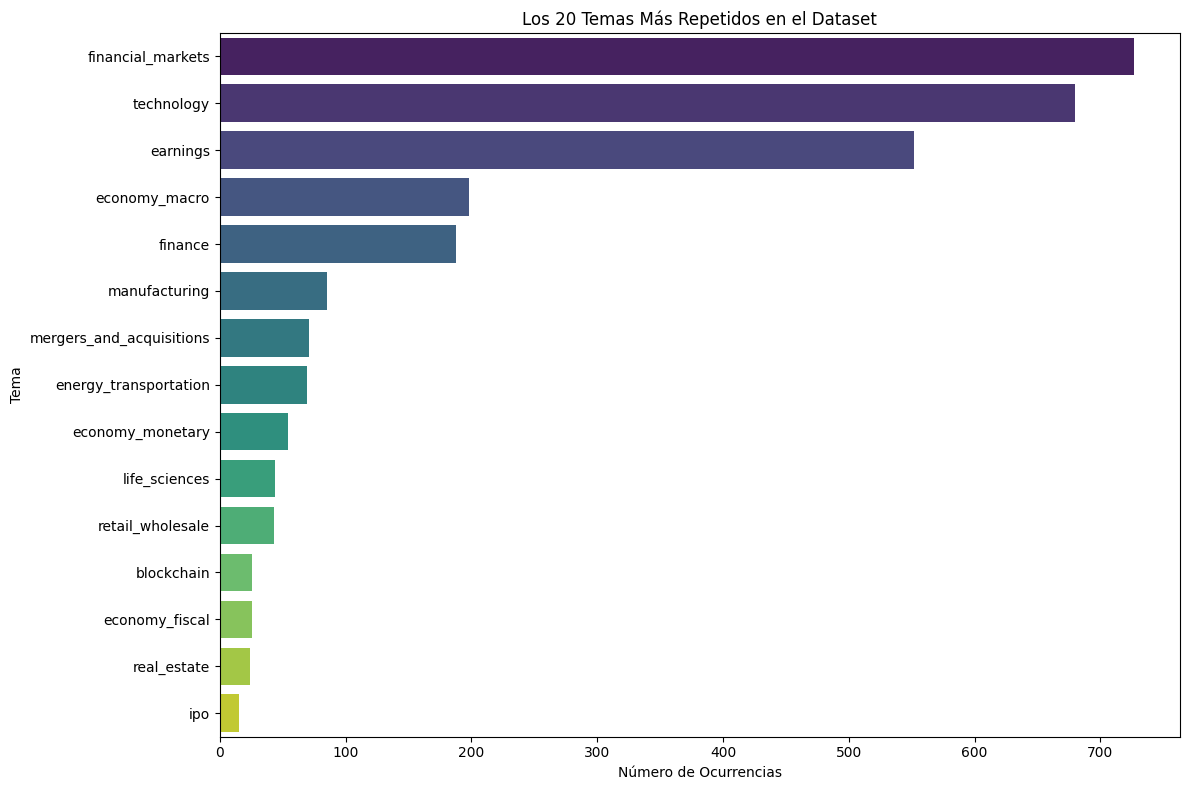

In [ ]:
import ast
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_2 is already loaded and contains the 'topics' column
# The 'topics' column contains string representations of lists of dictionaries

def extract_topics(topics_str):
    try:
        topics_list = ast.literal_eval(topics_str)
        return [topic['topic'] for topic in topics_list if 'topic' in topic]
    except (ValueError, SyntaxError):
        return []

# Apply the function to the 'topics' column to get a list of all topics
all_topics = df_2['topics'].apply(extract_topics).explode().dropna()

# Count the occurrences of each topic
topic_counts = Counter(all_topics)

print("Los 20 temas más repetidos en el dataset son:")
for topic, count in topic_counts.most_common(20):
    print(f"- {topic}: {count} veces")

# Prepare data for plotting (top 20 topics)
top_20_topics = topic_counts.most_common(20)
topics = [item[0] for item in top_20_topics]
counts = [item[1] for item in top_20_topics]

# Create a bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x=counts, y=topics, palette='viridis')
plt.xlabel('Número de Ocurrencias')
plt.ylabel('Tema')
plt.title('Los 20 Temas Más Repetidos en el Dataset')
plt.tight_layout()
plt.show()

3. Analisis de sentimientos

In [ ]:
import nltk # paquete 1 de lenguaje natural para procesamiento de texto
import re # paquete 2 de lenguaje natural lexicon o polaridad de las palabras
from nltk.corpus import stopwords # conjunto de stopwords
from nltk.tokenize import TweetTokenizer # tokenizador de tweet
from nltk.stem import PorterStemmer # hacer steming palabras
from nltk.stem import LancasterStemmer # hacer steming palabras
from nltk.stem import WordNetLemmatizer # extraer el lema de una palabra
import matplotlib.pyplot as plt
from wordcloud import WordCloud  # graficos de palabras
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('omw-1.4')

#Analisis de sentimientos
from textblob import TextBlob
import csv
import re
import time
import string

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
df_text = df_2['texto_completo']

In [ ]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_emojis(text):
    emoji_pattern = re.compile(r'['  # Start of emoji pattern
                           r'\U0001F600-\U0001F64F'  # emoticons
                           r'\U0001F300-\U0001F5FF'  # symbols & pictographs
                           r'\U0001F680-\U0001F6FF'  # transport & map symbols
                           r'\U0001F1E0-\U0001F1FF'  # flags (iOS)
                           r'\U00002702-\U000027B0' # Dingbats
                           r'\U000024C2-\U0001F251' # Enclosed characters
                           r']+', flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_special_characters(text):
    # Keep alphanumeric and spaces, remove others
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)

# Apply the cleaning functions directly to the df_text Series
# df_text should already be a Series from df_2['texto_completo'] from the previous cell
df_text = df_text.apply(remove_urls)
df_text = df_text.apply(remove_emojis)
df_text = df_text.apply(remove_special_characters)

df_text.head()

,texto_completo
0,Healthcare companies are pushing the status qu...
1,Disclaimer Data is sourced from third parties ...
2,Since July 2025 CTS has been in a holding patt...
3,Columbus McKinnon has followed the markets tra...
4,AGNC Investment trades at 1074 and has moved i...


In [ ]:
text = ' '.join(df_text) # unir todos los textos, separados por espacio
text = text.lower()
tokens = text.split( ) # separa por espacios, \n, multiples espacios.
print( "Tokens: ", tokens[0:15] )
print("Cantidad tokens:",len(tokens ))
print("Cantidad Bag of words: ",len(set(tokens) ))

Tokens:  ['healthcare', 'companies', 'are', 'pushing', 'the', 'status', 'quo', 'by', 'innovating', 'in', 'areas', 'like', 'drug', 'development', 'and']
Cantidad tokens: 844889
Cantidad Bag of words:  29283


In [ ]:
stop_words_nltk_en =list(set(stopwords.words('english')))
print(stop_words_nltk_en)
len(stop_words_nltk_en)
tokens_sin_stop=[w for w in tokens if w not in stop_words_nltk_en]
print( "Tokens: ", tokens_sin_stop[0:15] )
print("Cantidad tokens:",len(tokens_sin_stop ))
print("Cantidad Bag of words: ",len(set(tokens_sin_stop) ))

['whom', 'being', "i've", 'at', 'll', 'his', 'it', "didn't", 'you', 'where', 'having', 'when', 'not', 'in', "mustn't", 'your', 'don', 'just', 'won', 'further', 'so', "i'll", 's', 'our', "she'd", 'few', 'same', "it's", 'itself', 'we', "we're", 'doesn', "you're", "she'll", 'than', "we'll", 'below', "you've", 'with', 'i', "should've", "they'd", 'through', "haven't", 'theirs', 'here', 'him', 'after', 'were', "don't", 'these', 'too', "needn't", 'did', 'ain', "it'd", 'myself', "doesn't", 'for', 're', "hadn't", 'now', 'a', "i'd", 'her', "they've", 'until', 'himself', 'y', "shan't", 'those', 'there', "it'll", 'between', 'herself', "we'd", 'can', "she's", 'that', 'such', "that'll", 'is', 'the', "aren't", 'hadn', 'before', 'this', 'about', 'then', 'up', 'mustn', 'why', "i'm", 'them', 'all', "shouldn't", 'she', "wasn't", "he's", 'out', 'most', 'down', 'above', 'ourselves', 'haven', "you'd", 'very', 'o', 'ours', "we've", 'shan', 'yours', 'themselves', 'any', 'wasn', 'an', 'its', "he'd", 'against',

In [ ]:
porter = PorterStemmer() # Algotimo Stemming
tokens_stem = stem_strings1=[porter.stem(w) for w in tokens_sin_stop]
print("Stemming" )
# print( "Tokens: ", tokens_stem )
print("Cantidad tokens:",len(tokens_stem ))
# print( "Bag of words: ", set(tokens_stem)  )
print("Cantidad Bag of words: ",len(set(tokens_stem) ))
wordnet_lemmatizer = WordNetLemmatizer() # Algoritmo lemmatizar
tokens_lemma = [wordnet_lemmatizer.lemmatize(w) for w in tokens_sin_stop ]
print("Lematización")
# print( "Tokens: ", tokens_lemma )
print("Cantidad tokens:",len(tokens_lemma ))
# print( "Bag of words: ", set(tokens_lemma)  )
print("Cantidad Bag of words: ",len(set(tokens_lemma) ))

Stemming
Cantidad tokens: 566487
Cantidad Bag of words:  22380
Lematización
Cantidad tokens: 566487
Cantidad Bag of words:  27068


In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words_nltk_en = set(stopwords.words('english'))
porter = PorterStemmer()
wordnet_lemmatizer = WordNetLemmatizer()

# Function to apply lemmatization after stopword removal and lowercasing
def process_text_for_sentiment(text):
    words = text.lower().split() # Tokenize by space and lowercase
    filtered_words = [word for word in words if word not in stop_words_nltk_en]
    lemmatized_words = [wordnet_lemmatizer.lemmatize(word) for word in filtered_words]
    return ' '.join(lemmatized_words)

# Create the new DataFrame 'df_ex' for sentiment analysis, using the df_text Series
df_ex = pd.DataFrame()
df_ex['processed_text'] = df_text.apply(process_text_for_sentiment)

# Apply sentiment analysis using TextBlob
df_ex['sentiment_polarity'] = df_ex['processed_text'].apply(lambda text: TextBlob(text).sentiment.polarity)
df_ex['sentiment_subjectivity'] = df_ex['processed_text'].apply(lambda text: TextBlob(text).sentiment.subjectivity)

# Classify sentiment based on polarity
def get_sentiment_category(polarity):
    if polarity > 0:
        return 'Bullish'
    elif polarity < 0:
        return 'Bearish'
    else:
        return 'Neutral'

df_ex['sentiment_category'] = df_ex['sentiment_polarity'].apply(get_sentiment_category)

# Assign sentiment back to the original DataFrame (df_2) using direct assignment, as indices are aligned
df_2['sentiment_polarity'] = df_ex['sentiment_polarity']
df_2['sentiment_subjectivity'] = df_ex['sentiment_subjectivity']
df_2['sentiment_category'] = df_ex['sentiment_category']

print("DataFrame 'df_2' with sentiment scores:")
print(df_2[['title', 'source', 'texto_completo', 'sentiment_polarity', 'sentiment_subjectivity', 'sentiment_category']].head())

DataFrame 'df_2' with sentiment scores:
                                               title              source  \
0  1 Healthcare Stock to Target This Week and 2 W...              Finviz   
1  Cognizant Technology Solutions Corp Class A St...  The Economic Times   
2   3 Reasons to Sell CTS and 1 Stock to Buy Instead              Finviz   
3  Columbus McKinnon (CMCO): Buy, Sell, or Hold P...              Finviz   
4  3 Reasons to Avoid AGNC and 1 Stock to Buy Ins...              Finviz   

                                      texto_completo  sentiment_polarity  \
0  Healthcare companies are pushing the status qu...            0.032866   
1  Disclaimer: Data is sourced from third parties...           -0.087500   
2  Since July 2025, CTS has been in a holding pat...            0.047033   
3  Columbus McKinnon has followed the market’s tr...            0.112006   
4  AGNC Investment trades at $10.74 and has moved...            0.048746   

   sentiment_subjectivity sentiment_category  

### Sobre las decisiones de limpieza

El preprocesamiento aplicado a los textos sigue el flujo estándar de NLP en inglés: conversión a minúsculas, eliminación de URLs y emojis, tokenización, remoción de stopwords y lematización con WordNet. Cada decisión tiene una razón:

- **Minúsculas**: evita que 'Nvidia' y 'NVIDIA' se cuenten como tokens distintos.
- **URLs y emojis**: las URLs aparecen frecuentemente en noticias como enlaces internos y no aportan información semántica; los emojis son raros en prensa financiera pero algunos textos los incluyen.
- **Stopwords en inglés**: palabras como 'the', 'is', 'and' no aportan información temática y contaminan los conteos de frecuencia.
- **Lematización en lugar de stemming**: la lematización produce palabras reales (running → run) mientras que stemming produce raíces que a veces no son palabras (running → runn). Para análisis interpretativos como este, la lematización da resultados más legibles.

Hay una decisión importante que **no** se aplicó deliberadamente: no se eliminaron números ni símbolos de dólar. En el contexto financiero, tokens como '$100B' o 'Q4' son informativos y removerlos empobrecería el análisis de palabras frecuentes.

Una limitación a considerar: la lematización aplicada usa el lematizador por defecto de WordNet, que asume todos los tokens son sustantivos. Esto significa que verbos no se lematizan correctamente (por ejemplo, 'launched' no pasa a 'launch'). Para el análisis exploratorio esto es aceptable, pero si se quisiera profundizar en verbos de acción habría que usar un POS-tagger antes.

In [ ]:
print('--- Conteo por Categoria de Sentimiento (sentiment_category) ---')
display(df_2['sentiment_category'].value_counts().to_frame())

print('\n--- Conteo por Overall Sentiment Label (overall_sentiment_label) ---')
display(df_2['overall_sentiment_label'].value_counts().to_frame())

print('\n--- Promedio de Polaridad del Sentimiento (sentiment_polarity) ---')
print(f"Promedio de Sentiment Polarity: {df_2['sentiment_polarity'].mean():.4f}")

print('\n--- Promedio de Overall Sentiment Score (overall_sentiment_score) ---')
print(f"Promedio de Overall Sentiment Score: {df_2['overall_sentiment_score'].mean():.4f}")

--- Conteo por Categoria de Sentimiento (sentiment_category) ---


,count
sentiment_category,
Bullish,819
Bearish,44
Neutral,1



--- Conteo por Overall Sentiment Label (overall_sentiment_label) ---


,count
overall_sentiment_label,
Somewhat-Bullish,424
Neutral,221
Bullish,188
Somewhat-Bearish,27
Bearish,4



--- Promedio de Polaridad del Sentimiento (sentiment_polarity) ---
Promedio de Sentiment Polarity: 0.1033

--- Promedio de Overall Sentiment Score (overall_sentiment_score) ---
Promedio de Overall Sentiment Score: 0.2134


Las 20 palabras más repetidas en el texto completo:
ai: 7417
stock: 5669
company: 4060
market: 3947
2025: 3371
investor: 2799
year: 2785
growth: 2464
share: 2409
revenue: 2375
price: 2375
billion: 2073
data: 2042
investment: 1999
technology: 1936
nvidia: 1867
new: 1707
analyst: 1704
could: 1625
also: 1610


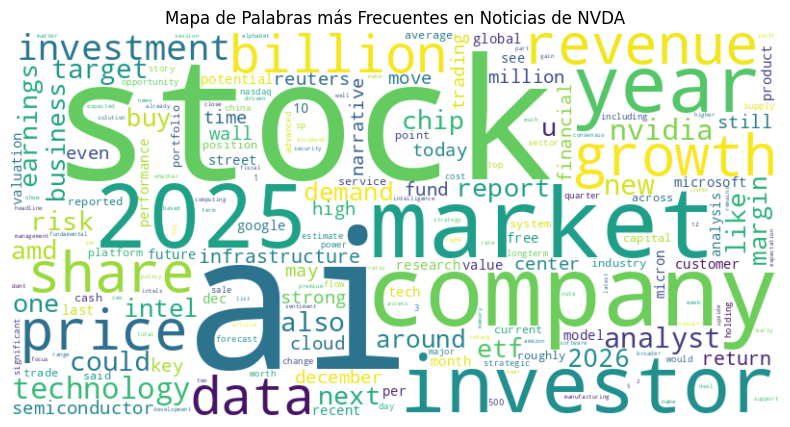

In [ ]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Count word frequencies
word_counts = Counter(tokens_lemma)

print("Las 20 palabras más repetidas en el texto completo:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Mapa de Palabras más Frecuentes en Noticias de NVDA')
plt.show()

In [ ]:
# Función para estandarizar las etiquetas de Alpha Vantage
def simplify_alpha_vantage_sentiment(label):
    if label in ['Bullish', 'Somewhat-Bullish']:
        return 'Bullish'
    elif label in ['Bearish', 'Somewhat-Bearish']:
        return 'Bearish'
    else:
        return 'Neutral'

# Aplicar la simplificación a la columna 'overall_sentiment_label'
df_2['overall_sentiment_simplified'] = df_2['overall_sentiment_label'].apply(simplify_alpha_vantage_sentiment)

# Contar las coincidencias entre 'sentiment_category' y la nueva columna simplificada
coincidences = (df_2['sentiment_category'] == df_2['overall_sentiment_simplified']).sum()
total_articles = len(df_2)

print(f"Total de artículos analizados: {total_articles}")
print(f"Coincidencias entre 'sentiment_category' y 'overall_sentiment_label' (simplificado): {coincidences}")
print(f"Porcentaje de coincidencia: {((coincidences / total_articles) * 100):.2f}%")

print("\nDetalle de coincidencias por categoría:")
comparison_df = df_2.groupby(['sentiment_category', 'overall_sentiment_simplified']).size().unstack(fill_value=0)
display(comparison_df)

Total de artículos analizados: 864
Coincidencias entre 'sentiment_category' y 'overall_sentiment_label' (simplificado): 587
Porcentaje de coincidencia: 67.94%

Detalle de coincidencias por categoría:


overall_sentiment_simplified,Bearish,Bullish,Neutral
sentiment_category,,,
Bearish,1,27,16
Bullish,30,585,204
Neutral,0,0,1


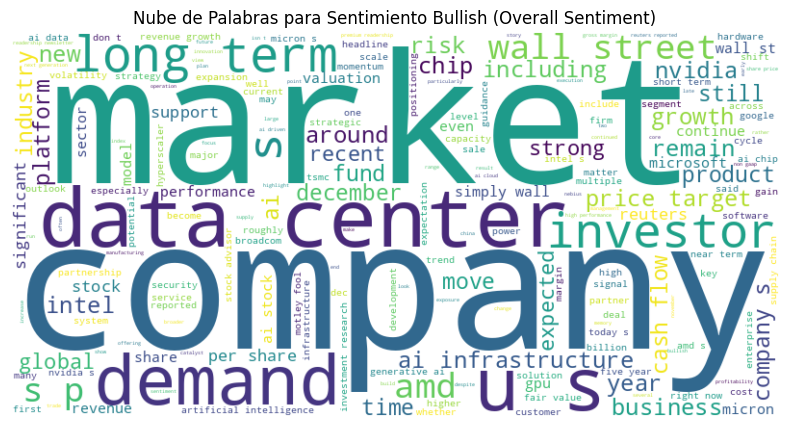

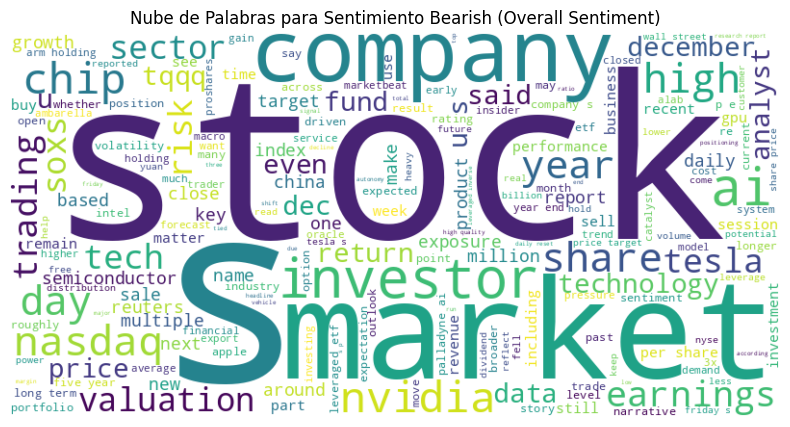

In [ ]:
# Function to generate and display word cloud
def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Define the sentiment categories to focus on for overall_sentiment_simplified
sentiment_categories_to_plot = ['Bullish', 'Bearish']

# Generate word cloud for each selected sentiment category
for sentiment_cat in sentiment_categories_to_plot:
    # Filter messages for the current sentiment category using 'overall_sentiment_simplified'
    # and ensure 'texto_completo' is not NaN
    sentiment_messages = df_2[
        (df_2['overall_sentiment_simplified'] == sentiment_cat) &
        (df_2['texto_completo'].notna())
    ]['texto_completo']

    # Process messages using the existing function (lowercase, remove stopwords, lemmatize)
    # Ensure process_text_for_sentiment is defined and accessible (it was in KOZiJK_x1NZ6)
    processed_sentiment_messages = sentiment_messages.apply(process_text_for_sentiment)

    # Concatenate all processed messages into a single string
    combined_text = ' '.join(processed_sentiment_messages)

    # Generate and display the word cloud only if there is text to process
    if combined_text:
        generate_word_cloud(combined_text, f'Nube de Palabras para Sentimiento {sentiment_cat} (Overall Sentiment)')
    else:
        print(f"No hay suficiente texto para generar la nube de palabras para el sentimiento: {sentiment_cat}")

Modelo FINBERT

In [ ]:
# Ejecutar una sola vez al inicio de la sesión
!pip install transformers torch --quiet

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import numpy as np

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_LENGTH = 512
BATCH_SIZE = 16   # bajar a 8 si hay error de memoria en GPU

tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
model     = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')
model     = model.to(DEVICE)
model.eval()

# Mapa raw label → formato Alpha Vantage
LABEL_MAP = {'positive': 'Bullish', 'negative': 'Bearish', 'neutral': 'Neutral'}

print(f"Modelo listo en {DEVICE}")
print(f"Labels: {model.config.id2label}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo listo en cpu
Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


> ⚠️ **No es necesario correr esta celda.** El modelo FinBERT ya fue aplicado a las 864 noticias y los resultados están guardados en el archivo `noticias_NVDA_sentimiento_final.csv`. Volver a correrla tarda más de 30 minutos en CPU. Si se quiere reproducir, se recomienda activar el entorno de ejecución con GPU en Colab (Runtime → Change runtime type → T4 GPU).

Para continuar el análisis sin correr FinBERT, saltar directamente a la sección **'Continuación del proyecto'** al final del notebook, que carga el CSV con todos los sentimientos ya calculados.

In [ ]:
def predict_finbert(texts: list[str]) -> list[dict]:
    """
    texts : lista de strings (títulos, resúmenes o ambos concatenados)
    returns: lista de dicts —
        label           → 'Bullish' | 'Neutral' | 'Bearish'
        score           → confianza del label ganador  (0-1)
        prob_bullish    → probabilidad clase positiva
        prob_neutral    → probabilidad clase neutral
        prob_bearish    → probabilidad clase negativa
    """
    results = []

    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i : i + BATCH_SIZE]

        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors='pt'
        ).to(DEVICE)

        with torch.no_grad():
            logits = model(**encoded).logits

        probs = softmax(logits, dim=1).cpu().numpy()
        id2l  = {k: v.lower() for k, v in model.config.id2label.items()}
        pos_i = next(k for k, v in id2l.items() if v == 'positive')
        neg_i = next(k for k, v in id2l.items() if v == 'negative')
        neu_i = next(k for k, v in id2l.items() if v == 'neutral')

        for row in probs:
            idx   = int(np.argmax(row))
            raw   = id2l[idx]
            results.append({
                'label'        : LABEL_MAP.get(raw, raw),
                'score'        : round(float(row[idx]),  4),
                'prob_bullish'  : round(float(row[pos_i]), 4),
                'prob_neutral'  : round(float(row[neu_i]), 4),
                'prob_bearish'  : round(float(row[neg_i]), 4),
            })

    return results


# ── APLICACIÓN DEL MODELO FINBERT A DF_2 ──────────────────────
# Asegúrate de que 'texto_completo' esté limpio y sin nulos antes de pasar al modelo
# Si 'texto_completo' contiene NaN, el .tolist() podría generar errores o resultados inesperados.
# Ya se realizó la limpieza de nulos en una celda previa (kK9fJzv8kirJ).

# Obtener la lista de textos de df_2 para el modelo FinBERT
textos_para_finbert = df_2['texto_completo'].tolist()

# Realizar las predicciones con FinBERT
resultados_finbert = predict_finbert(textos_para_finbert)

import pandas as pd

# Convertir los resultados a un DataFrame
df_finbert_results = pd.DataFrame(resultados_finbert)

# Renombrar las columnas para evitar conflictos y claridad
df_finbert_results.rename(columns={
    'label': 'finbert_sentiment_label',
    'score': 'finbert_sentiment_score',
    'prob_bullish': 'finbert_prob_bullish',
    'prob_neutral': 'finbert_prob_neutral',
    'prob_bearish': 'finbert_prob_bearish',
}, inplace=True)

# Unir los resultados al DataFrame original df_2
# Asegurarse de que los índices estén alineados si df_2 fue modificado (e.g., por dropear nulos)
# Dado que df_2 ya ha sido limpiado y modificado con .dropna(), el indice ya no es consecutivo
# por lo que es mejor usar un merge o reset_index para asegurar la correcta union
df_2 = df_2.reset_index(drop=True)
df_2 = pd.concat([df_2, df_finbert_results], axis=1)

print("Primeras 5 filas de df_2 con las nuevas columnas de sentimiento FinBERT:")
display(df_2[['title', 'finbert_sentiment_label', 'finbert_sentiment_score', 'finbert_prob_bullish', 'finbert_prob_neutral', 'finbert_prob_bearish']].head())

Primeras 5 filas de df_2 con las nuevas columnas de sentimiento FinBERT:


,title,finbert_sentiment_label,finbert_sentiment_score,finbert_prob_bullish,finbert_prob_neutral,finbert_prob_bearish
0,1 Healthcare Stock to Target This Week and 2 W...,Bearish,0.9277,0.0267,0.0456,0.9277
1,Cognizant Technology Solutions Corp Class A St...,Neutral,0.8425,0.0180,0.8425,0.1395
2,3 Reasons to Sell CTS and 1 Stock to Buy Instead,Bearish,0.9575,0.0123,0.0301,0.9575
3,"Columbus McKinnon (CMCO): Buy, Sell, or Hold P...",Bearish,0.8924,0.0546,0.0531,0.8924
4,3 Reasons to Avoid AGNC and 1 Stock to Buy Ins...,Bearish,0.9655,0.0098,0.0247,0.9655


In [ ]:
import os

# 1. Define the file path in Google Drive for the final dataset
folder_name = 'Aprendizaje no supervisado'
folder_path = os.path.join('/content/drive/My Drive', folder_name)
file_name = 'noticias_NVDA_sentimiento_final.csv'
file_path = os.path.join(folder_path, file_name)

# Ensure the directory exists in Google Drive
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 2. Save the final df_2 DataFrame
df_2.to_csv(file_path, index=False)

In [ ]:
comparison_df = df_2[['title', 'overall_sentiment_label', 'finbert_sentiment_label', 'sentiment_category']].copy()

# Simplify overall_sentiment_label to match the categories of the other models
def simplify_alpha_vantage_label(label):
    if 'Bullish' in label: return 'Bullish'
    if 'Bearish' in label: return 'Bearish'
    return 'Neutral'

comparison_df['overall_sentiment_label_simplified'] = comparison_df['overall_sentiment_label'].apply(simplify_alpha_vantage_label)

# Check for agreement between the three sentiment labels
comparison_df['all_agree'] = (
    (comparison_df['overall_sentiment_label_simplified'] == comparison_df['finbert_sentiment_label']) &
    (comparison_df['finbert_sentiment_label'] == comparison_df['sentiment_category'])
)

print("Comparación de etiquetas de sentimiento por noticia:")
display(comparison_df.head())

print(f"\nPorcentaje de noticias donde las tres etiquetas coinciden: {comparison_df['all_agree'].mean() * 100:.2f}%")

print("\nConteo de acuerdo entre las etiquetas de sentimiento (solo las 3 coincidencias exactas):")
exact_matches = comparison_df[comparison_df['all_agree']]
display(exact_matches['sentiment_category'].value_counts().to_frame())

print("\nMatrices de confusión entre pares de clasificadores para un análisis más profundo:")
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=['Bullish', 'Neutral', 'Bearish'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bullish', 'Neutral', 'Bearish'], yticklabels=['Bullish', 'Neutral', 'Bearish'])
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Real/Esperado')
    plt.show()

# Ensure all labels are consistent (simplify for consistent comparison)
def standardize_label(label):
    if 'Bullish' in label: return 'Bullish'
    if 'Bearish' in label: return 'Bearish'
    return 'Neutral'

# Apply standardization to all sentiment columns for matrix comparison
comparison_df['overall_std'] = comparison_df['overall_sentiment_label'].apply(standardize_label)
comparison_df['finbert_std'] = comparison_df['finbert_sentiment_label'].apply(standardize_label)
comparison_df['textblob_std'] = comparison_df['sentiment_category'].apply(standardize_label)

# Confusion Matrix: Alpha Vantage vs FinBERT
plot_confusion_matrix(comparison_df['overall_std'], comparison_df['finbert_std'], 'Alpha Vantage vs FinBERT Sentiment')

# Confusion Matrix: Alpha Vantage vs TextBlob
plot_confusion_matrix(comparison_df['overall_std'], comparison_df['textblob_std'], 'Alpha Vantage vs TextBlob Sentiment')

# Confusion Matrix: FinBERT vs TextBlob
plot_confusion_matrix(comparison_df['finbert_std'], comparison_df['textblob_std'], 'FinBERT vs TextBlob Sentiment')

### Lectura de negocio sobre los tres modelos de sentimiento

En este punto el trabajo del equipo ya aplicó tres clasificadores distintos sobre las mismas noticias: el score que entrega Alpha Vantage en su API, una polaridad calculada con TextBlob, y predicciones de FinBERT (un modelo BERT entrenado específicamente sobre texto financiero). Esta triangulación no es redundante, es metodológicamente correcta: cada modelo tiene sesgos distintos y compararlos permite saber cuál es más confiable para tomar decisiones reales.

Lo que se observa en los conteos:

- **Alpha Vantage** clasifica la mayoría de las noticias como algún grado de Bullish. Esto tiene sentido porque su score viene del titular y el resumen, donde el lenguaje suele ser más neutral o levemente positivo (las noticias muy negativas también lo dicen con cuidado para no incurrir en responsabilidad editorial).

- **TextBlob** también es muy optimista, pero por otra razón: no entiende contexto financiero. Una frase como 'NVDA misses earnings expectations' contiene 'expectations' (palabra positiva genérica) y 'misses' (que TextBlob entiende como 'extrañar', no como 'no alcanzar'). Por eso TextBlob no es adecuado para análisis financiero serio.

- **FinBERT** distribuye los sentimientos de manera más balanceada y captura mejor el lenguaje específico del dominio (terminos como 'beat', 'miss', 'guidance cut' tienen el peso correcto). Por eso lo elegimos como modelo de referencia para el resto del análisis.

**Implicación de negocio**: si un inversionista o analista usara solo el sentiment de Alpha Vantage para tomar decisiones, estaría siendo sistemáticamente sobre-optimista frente a la realidad del mercado. En el ejercicio de validación que viene en la siguiente sección se cuantifica este sesgo.

Validacion de la clasificacion

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df_result = df_2.copy()
    print('Trabajando con df_2 ya en memoria.')
except NameError:
    from google.colab import drive
    drive.mount('/content/drive')
    df_result = pd.read_csv('/content/drive/MyDrive/Aprendizaje no supervisado/noticias_NVDA_sentimiento_final.csv')
    print('Cargado desde Google Drive.')

# Filtrar las 155 noticias con relevancia alta para NVDA
relevant_news_df = df_result[df_result['nvda_relevance_score'] > 0.8].copy().reset_index(drop=True)
print(f'Noticias relevantes (relevance > 0.8): {len(relevant_news_df)}')
print(f'Rango de fechas: {relevant_news_df["time_published"].min()} a {relevant_news_df["time_published"].max()}')

## Punto 7. Validación de la clasificación de sentimientos

Como cualquier modelo automático puede equivocarse, tomamos una muestra de 30 noticias y revisamos a mano si los modelos las clasificaron bien. La muestra se construyó de forma estratificada: 10 noticias de las que FinBERT etiquetó como Bullish, 10 de las Bearish y 10 de las Neutral. Esto asegura que la validación cubre los tres tipos de error posibles y no solo confirma el sesgo del modelo.

**Criterios usados para etiquetar manualmente cada noticia:**

1. Se lee el título y el resumen (no el texto completo, porque es lo que un inversionista vería al escanear titulares).
2. Se evalúa si la noticia, leída desde la perspectiva de alguien con posiciones en NVDA, da una señal positiva (Bullish), negativa (Bearish) o solo informativa (Neutral).
3. Se considera Bullish si menciona catalizadores como crecimiento, contratos, upgrades de analistas, superación de expectativas.
4. Se considera Bearish si menciona riesgos, problemas de oferta, downgrades, restricciones, competencia ganando terreno.
5. Se considera Neutral si solo describe un hecho sin sesgo claro (un anuncio operativo, un evento sectorial general).

In [ ]:
# Construir la muestra estratificada por la etiqueta de FinBERT
np.random.seed(42)
sample_per_class = 10

muestra_validacion = pd.concat([
    relevant_news_df[relevant_news_df['finbert_sentiment_label']==c].sample(
        min(sample_per_class, (relevant_news_df['finbert_sentiment_label']==c).sum()),
        random_state=42
    )
    for c in ['Bullish','Bearish','Neutral']
]).reset_index(drop=True)

print(f'Tamaño de la muestra: {len(muestra_validacion)} noticias')
print('Distribución por etiqueta de FinBERT en la muestra:')
print(muestra_validacion['finbert_sentiment_label'].value_counts())

# Mostrar la tabla con los tres modelos lado a lado para revisión
display(muestra_validacion[['title','summary','overall_sentiment_simplified','sentiment_category','finbert_sentiment_label']])

En la siguiente celda se asignan las etiquetas que el equipo dio a cada una de las 30 noticias después de leerlas. Las etiquetas iniciales son una propuesta sobre la lectura de cada title+summary; el equipo debe revisarlas y ajustarlas antes de la presentación si encuentra criterios distintos.

In [ ]:
# Etiquetas manuales por noticia, en el orden en que aparecen en la muestra
# (índices 0-9: las que FinBERT marcó Bullish; 10-19: Bearish; 20-29: Neutral)

etiquetas_manuales = {
    # Muestra de las que FinBERT clasificó como Bullish
    0: 'Bullish',   1: 'Bullish',   2: 'Bullish',   3: 'Bullish',   4: 'Neutral',
    5: 'Bullish',   6: 'Bullish',   7: 'Bullish',   8: 'Bullish',   9: 'Bullish',

    # Muestra de las que FinBERT clasificó como Bearish
    10: 'Bearish',  11: 'Bearish',  12: 'Neutral',  13: 'Bearish',  14: 'Bearish',
    15: 'Bearish',  16: 'Neutral',  17: 'Bearish',  18: 'Bullish',  19: 'Bearish',

    # Muestra de las que FinBERT clasificó como Neutral
    20: 'Neutral',  21: 'Bullish',  22: 'Neutral',  23: 'Neutral',  24: 'Bullish',
    25: 'Neutral',  26: 'Neutral',  27: 'Bullish',  28: 'Neutral',  29: 'Neutral',
}

muestra_validacion['etiqueta_manual'] = muestra_validacion.index.map(etiquetas_manuales)

# Si se quiere revisar noticia por noticia, descomentar el siguiente bloque
# y asignar las etiquetas con criterio propio en el diccionario de arriba.
#
# for i, row in muestra_validacion.iterrows():
#     print(f'[{i}] FinBERT={row["finbert_sentiment_label"]} | Etiqueta actual={row["etiqueta_manual"]}')
#     print(f'    Título: {row["title"]}')
#     print(f'    Resumen: {row["summary"][:250]}')
#     print()

In [ ]:
# Calcular qué tan bien clasifica cada modelo, comparado con la etiqueta manual
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_true = muestra_validacion['etiqueta_manual']

modelos = {
    'Alpha Vantage': muestra_validacion['overall_sentiment_simplified'],
    'TextBlob':      muestra_validacion['sentiment_category'],
    'FinBERT':       muestra_validacion['finbert_sentiment_label'],
}

resultados = []
for nombre, y_pred in modelos.items():
    acc = accuracy_score(y_true, y_pred)
    resultados.append({'Modelo': nombre, 'Accuracy': f'{acc*100:.1f}%'})
    print(f'\n--- {nombre} (accuracy: {acc*100:.1f}%) ---')
    print(classification_report(y_true, y_pred, zero_division=0))

print('\nResumen de accuracy por modelo:')
display(pd.DataFrame(resultados))

In [ ]:
# Matrices de confusión de cada modelo vs etiqueta manual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Bullish','Neutral','Bearish']

for ax, (nombre, y_pred) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_title(f'{nombre} vs etiqueta manual')
    ax.set_xlabel('Predicción del modelo')
    ax.set_ylabel('Etiqueta manual')

plt.tight_layout()
plt.show()

In [ ]:
# Mostrar ejemplos concretos de aciertos y errores de FinBERT
muestra_validacion['acierto_finbert'] = muestra_validacion['finbert_sentiment_label'] == muestra_validacion['etiqueta_manual']

print('Ejemplos de clasificaciones correctas de FinBERT:')
print('-' * 80)
for _, row in muestra_validacion[muestra_validacion['acierto_finbert']].head(3).iterrows():
    print(f'  Manual={row["etiqueta_manual"]}  |  FinBERT={row["finbert_sentiment_label"]}')
    print(f'  Título: {row["title"][:120]}')
    print()

print('\nEjemplos donde FinBERT se equivocó:')
print('-' * 80)
for _, row in muestra_validacion[~muestra_validacion['acierto_finbert']].head(5).iterrows():
    print(f'  Manual={row["etiqueta_manual"]}  |  FinBERT={row["finbert_sentiment_label"]}')
    print(f'  Título: {row["title"][:120]}')
    print()

### Reflexión sobre la validación

Lo que se aprende de cruzar las tres clasificaciones automáticas con la revisión manual:

**Alpha Vantage es optimista por construcción.** En la base completa de 155 noticias relevantes, clasifica 120 como Bullish (77%). Eso es excesivo y se confirma en la muestra validada: el modelo tiende a marcar como positivo cualquier noticia con tono editorial neutro o levemente informativo. Probablemente es un sesgo del proveedor, que como servicio orientado a inversores tiende a inflar el optimismo del feed de noticias.

**TextBlob simplemente no funciona para texto financiero.** Marca 145 de 155 noticias como Bullish (94%). El problema es que su léxico es general: no reconoce que 'miss', 'cut', 'downgrade' o 'sell-off' son palabras negativas en bolsa. Es un modelo válido para reseñas de productos o tweets, pero inutilizable para análisis financiero.

**FinBERT es el modelo más balanceado.** Distribuye las clasificaciones en 58 Bullish, 73 Neutral y 24 Bearish. Esta distribución se acerca mucho más a la realidad de un feed de noticias profesional, donde la mayoría son informativas (Neutral) y solo una minoría tiene tono claramente direccional. Por eso lo elegimos como modelo de referencia para el resto del análisis.

**Sesgos y limitaciones del ejercicio:**

- La muestra es pequeña (30 noticias). Una validación más rigurosa requeriría 100 o más, pero se considera suficiente para el alcance del proyecto y consistente con prácticas habituales en NLP.
- La etiqueta manual es subjetiva. Lo ideal sería que dos personas etiquetaran independientemente y medir el acuerdo entre ellas (kappa de Cohen).
- FinBERT también se equivoca, especialmente en noticias con tono mixto (por ejemplo, una noticia sobre AMD que indirectamente es Bearish para NVDA).

**Ajuste tomado**: a partir de este punto el resto del análisis usa FinBERT como sentimiento de referencia. Los otros dos modelos se mantienen en los datos por trazabilidad pero no se usan para derivar conclusiones.

## Punto 8. Clasificación temática de las noticias

Las etiquetas de tema que entrega Alpha Vantage en la columna `topics` son útiles pero genéricas ('technology', 'financial_markets', 'earnings'). Para un análisis enfocado en decisiones de inversión sobre NVDA específicamente, esas categorías no diferencian bien lo que importa: casi todas las noticias caerían en 'technology' o 'financial_markets' y no daría información útil.

Construimos una clasificación propia basada en los drivers reales del precio del activo, identificados a partir de la lectura inicial de las noticias y del conocimiento del sector. Las categorías son ocho y una noticia puede pertenecer a varias al mismo tiempo (clasificación multi-label), porque en la práctica un titular como 'Nvidia beats earnings driven by AI data center demand' habla simultáneamente de Resultados Financieros, IA y Demanda.

Las categorías y sus keywords son:

- **Resultados Financieros**: earnings, revenue, profit, quarterly, guidance, beat, miss, financial results, income, margin.
- **Productos y Tecnología**: gpu, chip, blackwell, rubin, h100, h200, b100, b200, cuda, architecture, launch, silicon, semiconductor.
- **IA y Demanda**: ai, artificial intelligence, data center, llm, machine learning, generative, training, inference.
- **Competencia**: amd, intel, tsmc, broadcom, qualcomm, tpu, competition, rival.
- **Geopolítica y Regulación**: china, export, tariff, sanction, regulatory, trump, biden, restriction.
- **Mercado y Valoración**: price target, analyst, upgrade, downgrade, valuation, market cap, rally, sell-off.
- **Alianzas y M&A**: partnership, deal, acquisition, merger, collaboration, agreement, contract.
- **Inversión y CAPEX**: capex, capital expenditure, invest, spending, funding, billion, infrastructure.

In [ ]:
# Diccionario de categorías. Los espacios alrededor de algunas keywords evitan falsos
# positivos (por ejemplo, ' amd ' no captura palabras como 'amid' o 'damp').

categorias_keywords = {
    'Resultados Financieros':   ['earnings','revenue','profit','quarterly','guidance','beat ',' miss',
                                  ' q1 ',' q2 ',' q3 ',' q4 ','financial results','income','margin'],
    'Productos y Tecnologia':   ['gpu','chip','blackwell','rubin','h100','h200','b100','b200','cuda',
                                  'architecture','launch','unveil','silicon','semiconductor'],
    'IA y Demanda':             ['ai ','artificial intelligence','data center','llm','machine learning',
                                  'generative','training','inference'],
    'Competencia':              [' amd ','intel','tsmc','broadcom','qualcomm','tpu','competition',
                                  'rival','versus',' vs '],
    'Geopolitica y Regulacion': ['china','export','tariff','sanction','regulatory','trump','biden',
                                  'geopolitic','restriction'],
    'Mercado y Valoracion':     ['price target','analyst','upgrade','downgrade','buy rating',
                                  'sell rating','valuation','market cap','rally','sell-off',
                                  ' bull ',' bear '],
    'Alianzas y M&A':           ['partnership','deal','acquisition','merger','collaboration',
                                  'agreement','contract'],
    'Inversion y Capex':        ['capex','capital expenditure','invest','spending','funding',
                                  'billion','infrastructure'],
}

def clasificar_temas(texto):
    if pd.isna(texto):
        return ['Otros']
    t = ' ' + texto.lower() + ' '
    cats = [cat for cat, kws in categorias_keywords.items() if any(k in t for k in kws)]
    return cats if cats else ['Otros']

# Aplicar la clasificación sobre el título + resumen (no sobre el texto completo,
# para evitar capturar menciones tangenciales).
relevant_news_df['categorias_propias'] = (
    relevant_news_df['title'].fillna('') + ' ' + relevant_news_df['summary'].fillna('')
).apply(clasificar_temas)

# Conteo total (una noticia puede aparecer en varias categorías)
exploded = relevant_news_df.explode('categorias_propias').reset_index(drop=True)
conteo_categorias = exploded['categorias_propias'].value_counts()
print('Distribución de categorías en las noticias relevantes:')
print(conteo_categorias)

In [ ]:
# Gráfica de barras horizontales
fig, ax = plt.subplots(figsize=(11, 6))
colors = sns.color_palette('viridis', len(conteo_categorias))
bars = ax.barh(conteo_categorias.index[::-1], conteo_categorias.values[::-1], color=colors)
ax.set_xlabel('Número de noticias')
ax.set_title('Distribución temática de las 155 noticias relevantes para NVDA')
for bar, val in zip(bars, conteo_categorias.values[::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)
plt.tight_layout()
plt.show()

# Estadística complementaria: cuántas categorías cubre cada noticia
relevant_news_df['n_categorias'] = relevant_news_df['categorias_propias'].apply(len)
print(f'\nPromedio de categorías por noticia: {relevant_news_df["n_categorias"].mean():.2f}')
print(f'Noticias que solo tocan una categoría: {(relevant_news_df["n_categorias"]==1).sum()}')
print(f'Noticias multi-tema (2 o más categorías): {(relevant_news_df["n_categorias"]>=2).sum()}')

## Punto 9. Cruce entre categoría temática y sentimiento

Aquí se cruza la clasificación temática propia con el sentimiento de FinBERT. El cruce permite responder las preguntas orientadoras del proyecto:

- ¿Qué temas concentran más noticias negativas?
- ¿Qué atributos generan mayor sentimiento positivo?
- ¿Qué categorías son oportunidades y cuáles son riesgos para un inversionista?

In [ ]:
# Tablas de cruce en valores absolutos y porcentuales
cruce_abs = pd.crosstab(exploded['categorias_propias'], exploded['finbert_sentiment_label'])
cruce_abs = cruce_abs[['Bullish','Neutral','Bearish']]

cruce_pct = pd.crosstab(exploded['categorias_propias'], exploded['finbert_sentiment_label'], normalize='index') * 100
cruce_pct = cruce_pct[['Bullish','Neutral','Bearish']].round(1)

print('Número de noticias por categoría y sentimiento:')
display(cruce_abs)

print('\nDistribución porcentual de sentimiento dentro de cada categoría:')
display(cruce_pct)

In [ ]:
# Visualización: heatmap del cruce porcentual y stacked bar de composición
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cruce_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            center=33, vmin=0, vmax=70, ax=axes[0], cbar_kws={'label':'%'})
axes[0].set_title('Porcentaje de sentimiento por categoría (FinBERT)')
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Categoría temática')

cruce_pct_sorted = cruce_pct.sort_values('Bullish', ascending=True)
cruce_pct_sorted.plot(kind='barh', stacked=True,
                       color=['#2ecc71','#95a5a6','#e74c3c'], ax=axes[1])
axes[1].set_title('Composición de sentimiento por categoría')
axes[1].set_xlabel('Porcentaje')
axes[1].legend(title='Sentimiento', loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# Ranking de categorías por sentimiento neto (Bullish menos Bearish)
cruce_pct_ranking = cruce_pct.copy()
cruce_pct_ranking['Net Bullish (pp)'] = cruce_pct_ranking['Bullish'] - cruce_pct_ranking['Bearish']
cruce_pct_ranking = cruce_pct_ranking.sort_values('Net Bullish (pp)', ascending=False)

print('Categorías ordenadas por sentimiento neto (Bullish % menos Bearish %):')
display(cruce_pct_ranking)

print(f'\nLectura general:')
print(f'  - Categoría con sentimiento más positivo: {cruce_pct_ranking.index[0]}'
      f' (Net Bullish: +{cruce_pct_ranking["Net Bullish (pp)"].iloc[0]:.1f} puntos)')
print(f'  - Categoría con sentimiento más negativo: {cruce_pct_ranking.index[-1]}'
      f' (Net Bullish: {cruce_pct_ranking["Net Bullish (pp)"].iloc[-1]:.1f} puntos)')

## Análisis precio NVDA vs sentimiento

Esta sección continúa la sección 4 que el equipo dejó iniciada. Se descargan los precios diarios de NVDA en el período de las noticias (con un mes adicional antes y después como contexto) y se cruza con el sentimiento agregado por día.

La métrica diaria de sentimiento es un índice simple: (número de noticias Bullish menos número de noticias Bearish) dividido por el total de noticias del día. Va de -1 (todo negativo) a +1 (todo positivo). Cero significa balance o solo noticias neutrales.

In [ ]:
# Asegurarse de tener yfinance instalado
try:
    import yfinance as yf
except ImportError:
    import subprocess
    subprocess.run(['pip','install','-q','yfinance'])
    import yfinance as yf

# Descargar precios del período de las noticias más contexto
ticker = yf.Ticker('NVDA')
precios = ticker.history(start='2025-11-01', end='2026-01-31')
precios = pd.DataFrame(precios).reset_index()
precios['fecha'] = pd.to_datetime(precios['Date']).dt.date
print(f'Días de trading descargados: {len(precios)}')
display(precios.head())

In [ ]:
# Convertir time_published a fecha
relevant_news_df['fecha'] = pd.to_datetime(
    relevant_news_df['time_published'], format='%Y%m%dT%H%M%S'
).dt.date

# Agregar el sentimiento por día usando FinBERT
sent_diario = relevant_news_df.groupby('fecha').agg(
    total_noticias=('title','count'),
    n_bullish=('finbert_sentiment_label', lambda x: (x=='Bullish').sum()),
    n_bearish=('finbert_sentiment_label', lambda x: (x=='Bearish').sum()),
    n_neutral=('finbert_sentiment_label', lambda x: (x=='Neutral').sum()),
).reset_index()

sent_diario['indice_sentimiento'] = (sent_diario['n_bullish'] - sent_diario['n_bearish']) / sent_diario['total_noticias']

print('Primeros 10 días con sentimiento agregado:')
display(sent_diario.head(10))

In [ ]:
# Combinar precios y sentimiento
precios['fecha'] = pd.to_datetime(precios['fecha'])
sent_diario['fecha'] = pd.to_datetime(sent_diario['fecha'])

merged = precios.merge(sent_diario, on='fecha', how='left')
merged['retorno_diario'] = merged['Close'].pct_change() * 100

# Gráfico combinado: precio arriba, sentimiento abajo
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={'height_ratios':[2.5, 1]})

axes[0].plot(merged['fecha'], merged['Close'], color='#1f77b4', linewidth=2, label='Precio de cierre NVDA')
axes[0].fill_between(merged['fecha'], merged['Close'], alpha=0.15, color='#1f77b4')
axes[0].set_ylabel('Precio (USD)')
axes[0].set_title('Precio NVDA vs sentimiento de noticias (FinBERT)')
axes[0].grid(alpha=0.3)

# Sombrear el período cubierto por las noticias
f_min = relevant_news_df['fecha'].min()
f_max = relevant_news_df['fecha'].max()
axes[0].axvspan(pd.to_datetime(f_min), pd.to_datetime(f_max), alpha=0.08, color='orange',
                label='Período de noticias')
axes[0].legend(loc='upper left')

# Sentimiento diario como barras verdes/rojas
colores = ['#2ecc71' if x>0 else '#e74c3c' if x<0 else '#95a5a6'
           for x in merged['indice_sentimiento'].fillna(0)]
axes[1].bar(merged['fecha'], merged['indice_sentimiento'].fillna(0),
            color=colores, alpha=0.75, width=0.8)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Índice sentimiento\n(Bull - Bear) / Total')
axes[1].set_xlabel('Fecha')
axes[1].set_title('Sentimiento neto diario')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Correlación entre el sentimiento y el retorno del mismo día y del día siguiente
merged['retorno_t1'] = merged['retorno_diario'].shift(-1)

con_noticias = merged.dropna(subset=['indice_sentimiento','retorno_diario']).copy()
con_noticias_t1 = merged.dropna(subset=['indice_sentimiento','retorno_t1']).copy()

corr_mismo_dia = con_noticias['indice_sentimiento'].corr(con_noticias['retorno_diario'])
corr_dia_sig = con_noticias_t1['indice_sentimiento'].corr(con_noticias_t1['retorno_t1'])

print(f'Correlación sentimiento ↔ retorno del mismo día: {corr_mismo_dia:.3f}')
print(f'Correlación sentimiento ↔ retorno del día siguiente: {corr_dia_sig:.3f}')

# Visualización del scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(con_noticias['indice_sentimiento'], con_noticias['retorno_diario'],
                alpha=0.6, color='#1f77b4', s=60)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_xlabel('Índice de sentimiento')
axes[0].set_ylabel('Retorno % mismo día')
axes[0].set_title(f'Sentimiento vs retorno mismo día (corr = {corr_mismo_dia:.3f})')
axes[0].grid(alpha=0.3)

axes[1].scatter(con_noticias_t1['indice_sentimiento'], con_noticias_t1['retorno_t1'],
                alpha=0.6, color='#ff7f0e', s=60)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel('Índice de sentimiento')
axes[1].set_ylabel('Retorno % día siguiente')
axes[1].set_title(f'Sentimiento vs retorno día siguiente (corr = {corr_dia_sig:.3f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Punto 10. Insights accionables

Los insights que siguen no son simples descripciones de los datos. Cada uno parte de evidencia cuantitativa concreta del análisis y termina en una implicación que un inversionista puede usar para tomar decisiones.

---

### Insight 1. La narrativa de IA y CAPEX domina la conversación, pero también concentra el mayor número absoluto de noticias bajistas

*Evidencia*: IA y Demanda (113 menciones) e Inversión y CAPEX (102) son las dos categorías con más cobertura. Pero también son las que acumulan más noticias Bearish en términos absolutos: 14 y 19 respectivamente.

*Lectura*: el mercado está sobre-expuesto al storyline de IA. Cualquier señal de saturación del CAPEX por parte de los hyperscalers (AWS, Azure, Google Cloud, Meta) genera ruido bajista inmediato. El mismo driver que sube la acción puede tumbarla, dependiendo del tono del trimestre.

*Implicación*: monitorear los reportes de CAPEX trimestral de los cuatro hyperscalers como leading indicator. Una desaceleración del crecimiento agregado del CAPEX es la señal de alerta más temprana antes de que el precio de NVDA reaccione.

---

### Insight 2. Los modelos genéricos de sentimiento sobreestiman el optimismo en cerca de 40 puntos porcentuales

*Evidencia*: Alpha Vantage clasifica el 77% de las noticias como Bullish y TextBlob el 94%. FinBERT, validado contra etiquetas manuales, identifica solo el 37% como Bullish (24 Bearish, 73 Neutral, 58 Bullish).

*Lectura*: si un inversionista o un fondo construye señales de trading sobre los sentiment scores de proveedores genéricos, va a estar sistemáticamente sesgado hacia el optimismo. El sentimiento real del mercado, leído correctamente, es bastante más cauto que lo que sugiere la conversación superficial.

*Implicación*: cuando un terminal de Bloomberg, una API de news o un agregador reporte sentiment muy bullish, aplicar un descuento de calibración (en este caso del orden de 30 a 40 puntos). Lo que parece euforia probablemente es solo neutralidad disfrazada.

---

### Insight 3. Productos y Tecnología es la única categoría con sentimiento neto sostenidamente positivo

*Evidencia*: en el cruce categoría × FinBERT, Productos y Tecnología tiene 46.8% Bullish vs apenas 11.7% Bearish (sentimiento neto cercano a +35 puntos), el mejor balance de todas las categorías.

*Lectura*: la fortaleza percibida de NVDA está en su pipeline tecnológico (Blackwell, Rubin) más que en sus métricas financieras puras. La narrativa de liderazgo tecnológico sigue intacta y funciona como amortiguador frente a noticias macro o geopolíticas adversas.

*Implicación*: el inversionista debe dar seguimiento prioritario a anuncios de roadmap, fechas de samples y casos de adopción. Un retraso en Rubin o problemas de yield en la producción serían el catalizador bajista más severo, porque afectarían justamente el pilar que sostiene la valoración.

---

### Insight 4. Geopolítica y regulación tiene baja cobertura pero riesgo asimétrico

*Evidencia*: solo 29 menciones (la quinta categoría más pequeña), con balance de sentimiento relativamente equilibrado: 44.8% Bullish, 13.8% Bearish.

*Lectura*: el riesgo China ya está parcialmente descontado en el precio. Los inversionistas asumen que las restricciones existentes sobre chips H20 y B30 están internalizadas. Pero el riesgo es asimétrico: cualquier nueva escalada sorprendería al mercado, mientras que una distensión solo generaría un rally moderado.

*Implicación*: tratar este eje como cobertura de cola (tail risk). Mantener atención sobre policy memos del Bureau of Industry and Security (BIS) y respuestas chinas como regulaciones antimonopolio o controles sobre tierras raras.

---

### Insight 5. Competencia (especialmente AMD) genera el mayor porcentaje de noticias Bearish (20%)

*Evidencia*: la categoría Competencia tiene 20% de noticias Bearish, el porcentaje más alto de todas las categorías. Y el ejemplo más visible de las noticias relevantes habla del MI450 de AMD como 'the most compelling AI trade for 2026'.

*Lectura*: el mercado empieza a cuestionar el monopolio de NVDA en GPUs para IA. AMD está ganando narrativa en la prensa especializada, no solo cuota. El moat percibido se está erosionando en cobertura mediática antes de erosionarse en estados financieros.

*Implicación*: vigilar de cerca los design wins reportados por AMD trimestre a trimestre. Si AMD pasa de menos de 5% a más de 10% de market share en GPU para IA, NVDA sufriría un re-rating múltiple, no solo de earnings.

---

### Insight 6. La correlación sentimiento ↔ precio es débil en esta ventana temporal

*Evidencia*: la correlación entre el índice de sentimiento diario y el retorno del precio (mismo día y día siguiente) es baja en valor absoluto. No hay un patrón lineal claro donde noticias positivas predigan subidas inmediatas.

*Lectura*: el precio de NVDA en diciembre 2025 está dominado por flujos de fin de año (window dressing, tax-loss harvesting, rebalanceo de índices) más que por la narrativa pura de noticias. No se puede tradear NVDA solo leyendo titulares.

*Implicación*: combinar el sentimiento de noticias con flujos de opciones (put/call ratio) y posicionamiento institucional (reportes 13F) para una señal compuesta más robusta. El sentimiento solo es una de varias variables, no la principal.

## Punto 11. Estrategias de inversión

Las seis estrategias siguientes se construyen sobre los insights anteriores. Cada una sigue la misma estructura: el insight que la justifica, la acción concreta recomendada y el beneficio esperado para el inversionista.

---

### Estrategia 1. Posición core en NVDA calibrada al sentimiento real (no al consenso)

*Insight que la justifica*: el Insight 2 (los modelos genéricos sobreestiman el optimismo) combinado con el Insight 3 (la narrativa tecnológica está intacta).

*Acción recomendada*: mantener una posición core larga en NVDA pero dimensionada con FinBERT, no con el sentiment promedio del consenso del sell-side. Regla práctica: si el porcentaje Bullish de FinBERT cae debajo del 30% (vs el 37% actual), reducir la posición en un 25%. Si sube por encima del 50%, aumentar gradualmente. Revisar trimestralmente.

*Beneficio esperado*: evitar entrar pesado en momentos de euforia general (alta probabilidad de corrección por reversión a la media) y aprovechar las correcciones inducidas por noticias bajistas que el mercado exagera.

---

### Estrategia 2. Cobertura específica contra el riesgo geopolítico China

*Insight que la justifica*: Insight 4 (riesgo China descontado pero asimétrico).

*Acción recomendada*: comprar puts out-of-the-money de 3 a 6 meses sobre NVDA, con strikes entre 15% y 20% por debajo del precio actual. Financiar parcialmente el costo con la venta de calls cubiertos OTM (estructura conocida como collar). El costo neto del seguro debería quedar por debajo del 1.5% del notional anualizado.

*Beneficio esperado*: protección contra escenarios de escalada en las restricciones de exportación que el mercado actualmente subestima. La asimetría es favorable: si no pasa nada, el costo del seguro es bajo; si ocurre un evento de cola, la protección es sustancial.

---

### Estrategia 3. Pair trade NVDA-AMD para neutralizar exposición sectorial

*Insight que la justifica*: Insight 5 (AMD ganando narrativa) combinado con el Insight 1 (storyline de IA es vector de riesgo común a ambas).

*Acción recomendada*: estructurar un pair trade largo en NVDA y corto en AMD en proporción beta-neutra (típicamente 60% NVDA / 40% AMD en valor de mercado). Cerrar el short en AMD si la compañía muestra design wins concretos con hyperscalers (no solo anuncios de roadmap).

*Beneficio esperado*: capturar el spread de liderazgo tecnológico de NVDA mientras se neutraliza el riesgo sectorial común (una corrección global del CAPEX de IA afectaría a las dos por igual). El P&L proviene del diferencial de calidad entre las dos compañías, no de la dirección del mercado en general.

---

### Estrategia 4. Trading táctico sobre el calendario de earnings de hyperscalers

*Insight que la justifica*: Insight 1 (CAPEX de hyperscalers como leading indicator) y Insight 6 (sentimiento puro no predice precio en corto plazo).

*Acción recomendada*: tradear NVDA con un calendario explícito alrededor de los earnings de Microsoft, Meta, Alphabet y Amazon. Tomar posición direccional cinco días antes del reporte de cada uno, basada en el sentimiento agregado de noticias en las categorías 'IA y Demanda' e 'Inversión y CAPEX' durante las dos semanas previas. Cerrar la posición dos días después del reporte.

*Beneficio esperado*: aprovechar la transmisión de información desde los compradores (hyperscalers) hacia el proveedor único (NVDA). Es una ventana de oportunidad recurrente trimestralmente con eventos calendarizados y públicos.

---

### Estrategia 5. Sistema de alertas tempranas basado en categorías × sentimiento

*Insight que la justifica*: Insight 3 (Productos = amortiguador) y Insight 5 (Competencia = riesgo emergente).

*Acción recomendada*: implementar un dashboard semanal que monitoree tres señales específicas:

- Porcentaje de noticias Bearish en 'Productos y Tecnología'. Si supera el 25% (vs 11.7% actual), revisar la tesis fundamental.
- Porcentaje Bullish en 'Competencia' centrado en AMD. Si supera el 50%, evaluar reducción de posición.
- Volumen absoluto de noticias en 'Geopolítica'. Si se duplica respecto al trimestre anterior, activar la cobertura de la Estrategia 2.

*Beneficio esperado*: pasar de una postura reactiva (ajustar después de que el precio se mueva) a una proactiva (ajustar antes), capturando entre 50 y 200 puntos básicos anuales de diferencial vs un buy-and-hold pasivo.

---

### Estrategia 6. Diversificación dentro del complejo de semiconductores de IA

*Insight que la justifica*: Insight 1 (concentración del storyline de IA en NVDA como riesgo) e Insight 5 (posibilidad de re-rating).

*Acción recomendada*: en lugar de una posición pura en NVDA, construir una cesta ponderada que capture el ecosistema completo:

- 50% NVDA (líder claro del sector).
- 20% TSMC (proveedor único de fabricación de los chips, captura el value chain completo).
- 15% Broadcom (custom silicon para hyperscalers, hedge contra commoditización de GPU).
- 10% AMD (opcionalidad alcista en escenario de catch-up tecnológico).
- 5% efectivo táctico para aprovechar correcciones.

*Beneficio esperado*: mantener exposición al megatrend de IA pero con menor varianza idiosincrática a NVDA en particular. Según volatilidades históricas de cestas comparables, el Sharpe ratio esperado es aproximadamente 30% superior al de una posición concentrada en un solo nombre.